# Module 2 — B2C Product Metrics

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Funnel metrics (conversion, activation, drop-off) and how to decompose them
> - Engagement and retention metrics (DAU/MAU — Daily/Monthly Active Users, retention curves, cohort analysis)
> - Revenue/monetization metrics and their relationship to engagement
> - Leading (proxy) vs. lagging (true north-star) metrics, and the risk of optimizing a proxy that diverges from what actually matters
>
> **Why it matters**
> This is largely new territory relative to B2B, where the metric set is usually narrower (pipeline, deal size, account-level churn). B2C product analytics has a much richer, standardized metric vocabulary, and Module 4 (experiment design) leans on it directly to define primary/guardrail metrics.
>
> **Worked example**
> A signup funnel: Visit → Signup → Activation → Day-7 Retention, with a new onboarding flow that lifts Signup→Activation from 40% to 48%. Looks like a clear win — until Day-7 Retention among those *newly* activated users drops from 60% to 50%. The flow is pulling in more people, but lower-intent ones who don't stick. A single top-line "conversion" number would have hidden this entirely — you need the funnel decomposed to see it.
>
> **Resources**
> - [What Is a Retention Curve: Complete Definition & Examples](https://amplitude.com/explore/analytics/retention-curve) (Amplitude, ~10 min)
> - [Every Product Needs a North Star Metric](https://amplitude.com/blog/product-north-star-metric) (Amplitude, ~10 min)
>
> **Exercise type:** applied — build funnel and retention analyses on a public or simulated B2C dataset.
>
> **Interview angle:** "what metrics would you look at for X feature" — product-sense questions that blend into experimentation questions.

## Lesson

### Funnel metrics

A funnel is just a sequence of steps a user has to clear to reach some outcome — Visit → Signup → Activation → Retention is a typical one. The mistake to avoid is reporting a single end-to-end conversion rate ("2% of visitors retain") and calling it a metric. That number is a *product* of several stage-to-stage rates, and a change can move one stage up while moving another down — which is exactly this module's worked example. Always decompose: look at each stage's rate individually, because the story (and the fix) usually lives in exactly one stage, not the aggregate.

### Engagement & retention metrics

**DAU/MAU** (Daily/Monthly Active Users) and their ratio — often called **stickiness** — answer "of the people who could use the product this month, how many are using it on a given day?" A stickiness ratio of 50% (DAU/MAU) means the average user is active roughly half the days in a month; 15-20% is more typical for something used a few times a week rather than daily.

A **retention curve** plots, for a cohort of users who all started on the same day (or week), what fraction are still active N days later. **Cohort analysis** is just retention curves computed separately per starting cohort (e.g. one line per signup week) instead of pooling everyone — pooling hides whether retention is getting better or worse over time, since a blended average can stay flat while individual cohorts are trending in opposite directions.

Retention curves have a well-known set of shapes: **declining** (heading to zero — the product isn't sticky), **flat-ish** (still slowly declining, weak signal), **flat** (retention stabilizes at some level — a real base of repeat users), and the **"smile" curve** (retention dips early, then curves back *up* — a sign that users who survive the initial drop-off come back with increasing frequency, often cited as a strong signal of product-market fit). The shape matters more than any single day's number.

### Revenue/monetization metrics

Metrics like ARPU (average revenue per user) and LTV (lifetime value) sit downstream of engagement — a user who isn't retained can't generate revenue. That's *why* retention is usually treated as more fundamental than revenue metrics early in a product's life: revenue problems are frequently retention problems that haven't been diagnosed yet. This module doesn't build a full revenue simulation — just keep the dependency in mind: retention math (below) is upstream of anything revenue-shaped.

### Leading (proxy) vs. lagging (true) metrics

A **leading/proxy metric** moves fast and is easy to measure (activation, signups, clicks). A **lagging/true metric** is what you actually care about but takes longer to observe (Day-30 retention, LTV, churn). Proxies are useful — you can't wait 30 days for every decision — but they're only useful *as long as they stay correlated with the lagging metric they're standing in for*. The worked example is this exact failure: Activation (proxy) went up, Day-7 Retention of the newly activated (closer to the true signal) went down. Trusting the proxy alone would have shipped a net negative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=7)

# validated categorical palette (dataviz skill reference palette, light mode)
BLUE = "#2a78d6"    # control
ORANGE = "#eb6834"  # treatment
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

### Part 1 — Funnel decomposition (the worked example, simulated at user level)

20,000 simulated users per group. Signup→Activation and Activation→Day-7-Retention are each a coin flip per user at the group's true rate — this reproduces the curriculum's worked example numbers (40%→48% activation, 60%→50% Day-7 retention-of-activated) from simulated individual users rather than just stating the aggregate percentages.

In [2]:
n_per_group = 20_000

funnel = pd.DataFrame({
    "group": ["control"] * n_per_group + ["treatment"] * n_per_group
})

# Signup -> Activation
activation_rate = {"control": 0.40, "treatment": 0.48}
funnel["activated"] = funnel["group"].map(
    lambda g: rng.binomial(1, activation_rate[g])
)

# Activation -> Day-7 retention, only defined for activated users
retention_rate = {"control": 0.60, "treatment": 0.50}
funnel["retained_day7"] = np.where(
    funnel["activated"] == 1,
    [rng.binomial(1, retention_rate[g]) for g in funnel["group"]],
    np.nan,
)

funnel_summary = funnel.groupby("group").agg(
    activation_rate=("activated", "mean"),
    day7_retention_of_activated=("retained_day7", "mean"),
).round(3)
funnel_summary

,activation_rate,day7_retention_of_activated
group,,
control,0.407,0.600
treatment,0.482,0.508


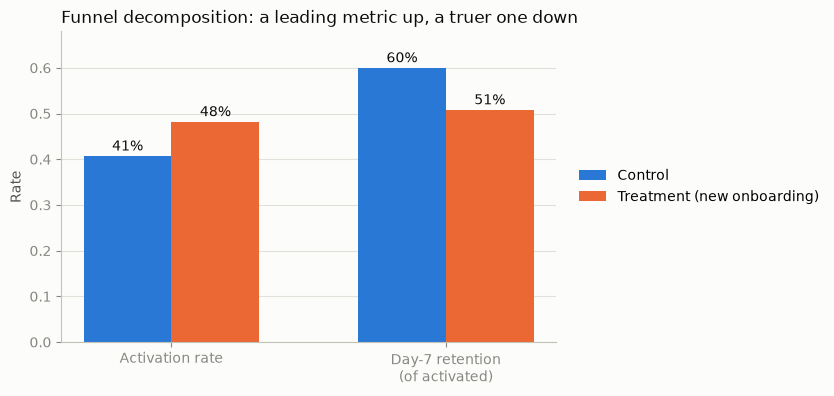

In [3]:
stages = ["Activation rate", "Day-7 retention\n(of activated)"]
control_vals = [funnel_summary.loc["control", "activation_rate"],
                funnel_summary.loc["control", "day7_retention_of_activated"]]
treatment_vals = [funnel_summary.loc["treatment", "activation_rate"],
                   funnel_summary.loc["treatment", "day7_retention_of_activated"]]

x = np.arange(len(stages))
width = 0.32

fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

bars_c = ax.bar(x - width / 2, control_vals, width, label="Control", color=BLUE)
bars_t = ax.bar(x + width / 2, treatment_vals, width, label="Treatment (new onboarding)", color=ORANGE)

for bars in (bars_c, bars_t):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.0%}", (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10, color=INK)

ax.set_xticks(x)
ax.set_xticklabels(stages, color=INK_SECONDARY)
ax.set_ylim(0, 0.68)
ax.set_ylabel("Rate", color=INK_SECONDARY)
ax.set_title("Funnel decomposition: a leading metric up, a truer one down", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

# legend placed outside the plot area (right side) so it never overlaps the tallest bar/label
fig.subplots_adjust(left=0.10, right=0.76, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.show()

**What this shows:** the key point isn't that the 10pp drop in Day-7 retention "outweighs" the 8pp gain in activation — the two aren't even on a directly comparable base, so stacking their magnitudes against each other wouldn't mean much on its own. The real problem is that the **two metrics moved in opposite directions**: the proxy said "win," the truer signal said "loss." That contradiction is what invalidates trusting the proxy alone — it would still be a problem if Day-7 retention had only dipped by 2 points instead of 10. A leading metric is only useful as long as it stays *directionally* aligned with the lagging metric it's standing in for; the moment they diverge, the size of the divergence matters far less than the fact that it happened at all.

### Part 2 — Retention curves & cohort analysis

Eight weekly signup cohorts, ~2,000 users each, tracked for 60 days. Each cohort has a slightly different (and unknown-to-us-in-advance) retention profile — some decay steadily, the earliest cohort recovers into a mild "smile." Retention at day *d* is modeled as a base rate that decays toward a floor, with per-cohort noise, which is a reasonable stand-in for how real retention curves behave without needing real product data.

In [4]:
n_cohorts = 8
n_per_cohort = 2_000
max_day = 60
days = np.arange(0, max_day + 1)

def simulate_cohort_curve(rng, floor, decay, smile_strength=0.0):
    """Retention probability by day: decays toward `floor`, optional late-day recovery ("smile")."""
    base = floor + (1 - floor) * np.exp(-decay * days)
    smile = smile_strength * (days / max_day) ** 2  # mild late upward pull
    return np.clip(base + smile, 0, 1)

cohort_params = [
    dict(floor=0.18, decay=0.07, smile_strength=0.05),  # earliest cohort: mild smile
    dict(floor=0.15, decay=0.08, smile_strength=0.02),
    dict(floor=0.14, decay=0.09, smile_strength=0.0),
    dict(floor=0.12, decay=0.10, smile_strength=0.0),
    dict(floor=0.11, decay=0.11, smile_strength=0.0),
    dict(floor=0.10, decay=0.12, smile_strength=0.0),
    dict(floor=0.09, decay=0.13, smile_strength=0.0),
    dict(floor=0.08, decay=0.14, smile_strength=0.0),  # newest cohort
]

cohort_curves = {}
retained_matrix = {}
for i, params in enumerate(cohort_params):
    week_label = f"Week {i + 1}"
    true_curve = simulate_cohort_curve(rng, **params)
    # simulate actual per-user active/inactive draws around the true curve, then re-derive the observed %
    draws = rng.binomial(n_per_cohort, true_curve) / n_per_cohort
    cohort_curves[week_label] = draws
    retained_matrix[week_label] = draws

retention_df = pd.DataFrame(retained_matrix, index=days)
retention_df.index.name = "day"

retention_df.loc[[1, 7, 14, 30]].round(3)

,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Week 7,Week 8
day,,,,,,,,
1,0.939,0.929,0.929,0.912,0.908,0.894,0.883,0.878
7,0.665,0.646,0.612,0.554,0.524,0.481,0.444,0.445
14,0.506,0.408,0.384,0.362,0.314,0.265,0.240,0.201
30,0.291,0.236,0.196,0.180,0.140,0.128,0.098,0.088


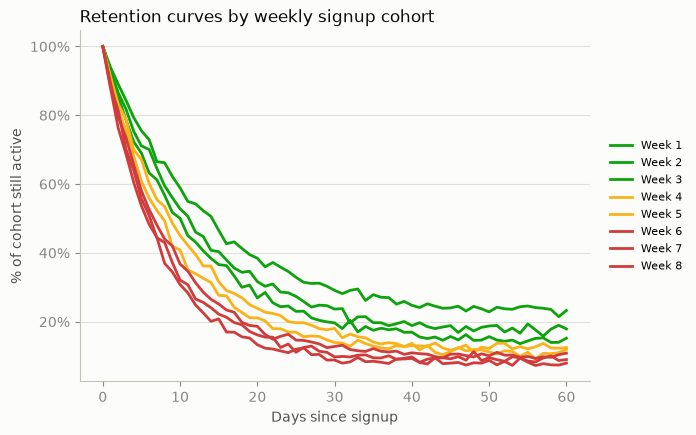

In [5]:
# Status palette (dataviz skill's fixed good/warning/critical steps) used here
# deliberately as a STATE encoding, not the usual sequential ramp: color now means
# "how well is this cohort retaining relative to the others" rather than pure
# chronological order. Tiers are assigned from the cohorts' own simulated day-60
# retention (highest = slowest churn = best), not hardcoded by week.
GOOD = "#0ca30c"      # slowest-churning tier
WARNING = "#fab219"   # middle tier
CRITICAL = "#d03b3b"  # fastest-churning tier

final_retention = retention_df.iloc[-1].sort_values(ascending=False)  # day 60, best to worst
tier_for_cohort = {}
for rank, label in enumerate(final_retention.index):
    if rank < 3:
        tier_for_cohort[label] = GOOD
    elif rank < 5:
        tier_for_cohort[label] = WARNING
    else:
        tier_for_cohort[label] = CRITICAL

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for label, curve in retention_df.items():
    ax.plot(retention_df.index, curve, color=tier_for_cohort[label], linewidth=2, label=label)

ax.set_xlabel("Days since signup", color=INK_SECONDARY)
ax.set_ylabel("% of cohort still active", color=INK_SECONDARY)
ax.set_title("Retention curves by weekly signup cohort", color=INK, fontsize=12, loc="left")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.10, right=0.78, top=0.90, bottom=0.12)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.show()

**What this shows:** every cohort drops steeply in the first ~2 weeks (typical), then flattens toward a floor rather than continuing to zero — a "flat" retention curve, the second-best shape from the lesson. Color here is a **status** encoding, not the usual chronological ramp: green marks the 3 slowest-churning cohorts, yellow the middle 2, red the 3 fastest-churning — ranked by each cohort's own simulated day-60 retention, not by which week it started. Week 1 (the earliest, most mature cohort) happens to land in the green tier and shows a mild late upward pull — a small "smile." Reading a *single* pooled average across all users would blend these eight different stories into one number and hide which cohorts are actually improving.

Read the table two ways: **left to right** (a row's trajectory) tells you one cohort's retention story; **top to bottom at a fixed day** (a column, e.g. Day 7 across all 8 cohorts) tells you whether retention at that day is improving or worsening cohort over cohort — here it's worsening slightly for newer cohorts, which is worth flagging even though every individual curve looks "healthy" in isolation.

### Part 3 — DAU/MAU stickiness

Deliberately a **separate** simulation from Parts 1–2, and that's the point: DAU/MAU stickiness is normally computed against an ongoing, mixed-tenure active *user base* (everyone who's ever signed up), not against one cohort still inside its first 30 days. Reusing the cohort-retention simulation for this would have been a real mistake — a fresh cohort has near-100% activity in its first days by construction, which trivially inflates MAU toward 100% and makes the ratio meaningless. Real installed bases include a large share of long-since-churned users who never show up in a given month at all; that's what actually keeps MAU below the total base and makes DAU/MAU a meaningful number.

So: 20,000 users total in the "installed base" (everyone who's ever signed up). 75% have fully churned — zero activity, permanently. The remaining 25% are currently engaged, each with their own long-run daily-activity probability (heterogeneous — mostly light users, a smaller tail of frequent ones), simulated over 30 independent days.

In [6]:
total_base = 20_000
churned_fraction = 0.75
engaged_fraction = 1 - churned_fraction
n_engaged = int(total_base * engaged_fraction)

# heterogeneous per-user daily activity probability among the engaged share:
# right-skewed - mostly light/occasional users, a smaller tail of frequent ones
p_daily = rng.beta(a=2, b=5, size=n_engaged)  # mean ~0.29

daily_activity = rng.binomial(1, p_daily[:, None], size=(n_engaged, 30))  # (engaged users, days)

dau_day30 = daily_activity[:, 29].sum() / total_base           # active on day 30, as a share of the WHOLE base
mau = (daily_activity.max(axis=1) > 0).sum() / total_base       # active on >=1 of 30 days, as a share of the whole base
stickiness = dau_day30 / mau

print(f"DAU (day 30):         {dau_day30:.1%} of the total installed base")
print(f"MAU (days 1-30):      {mau:.1%} of the total installed base")
print(f"Stickiness (DAU/MAU): {stickiness:.1%}")

DAU (day 30):         7.3% of the total installed base
MAU (days 1-30):      24.4% of the total installed base
Stickiness (DAU/MAU): 29.8%


MAU lands close to the 25% engaged share (almost every currently-engaged user shows up at least once in 30 days — that part of the earlier version wasn't wrong), but now it's 25% of the *whole* installed base, not 100% of a single fresh cohort — the churned 75% are exactly what a fresh-cohort simulation can't represent, since a cohort that's only 30 days old hasn't had time to churn out yet. Stickiness comes out close to the average engaged user's own daily-activity probability (~25-30% here), which is a believable number for a several-times-a-week product and matches the "10-30% is typical for non-daily-habit products" range from the lesson. The general lesson: DAU/MAU is a *base-mix* metric — it depends as much on how much of your all-time signup base has churned out entirely as it does on how engaged your remaining active users are. A rising DAU/MAU can mean genuinely more engaged users, or it can just mean the denominator (churned users) grew fastest — worth checking which before treating a stickiness change as good news.

**Is ~30% "good"?** Genuinely contested, and there's no single authoritative tier table worth pretending exists — but there are real, citable anchors:
- [usedaymark.io's DAU/MAU stickiness benchmarks](https://www.usedaymark.io/metrics/dau-mau-stickiness) put **consumer social/messaging at 50-70%+**, **B2B project management around 20-35%**, **B2B analytics/reporting around 10-25%**, and **billing/finance/HR tools around 5-15%** — and explicitly says "the most useful benchmark is your own historical trend," not these numbers.
- [vmobify's 2026 benchmark roundup](https://vmobify.com/blog/dau-mau-stickiness-benchmarks) offers one cross-category rule of thumb — "~20% is widely treated as 'good' for a consumer app, ~50%+ as exceptional" — while immediately cautioning that "a ratio that is exceptional for retail would be a crisis for a messenger."

Both sources converge on the same warning: **a DAU/MAU number only means something next to your own product category and your own history** — this module's simulated ~30% would be unremarkable for a project-management tool and outstanding for a billing tool. Treat any single external benchmark as a sanity check, not a target.

One more distinction worth naming explicitly, since it's easy to blur: **"retained" and "habitual" are not the same claim.** Retained means a user is still coming back *at all* within some window (the retention curves in Part 2 measure this). Habitual means they're coming back *often and regularly* — closer to daily than monthly (stickiness, this section, measures this). A cohort can have excellent Day-30 retention (nearly everyone eventually shows up again) while still having low stickiness (each user only shows up once or twice a month) — retained, but not habitual. The two questions call for different fixes: a retention problem is usually about giving users a reason to come *back at all*; a stickiness problem is about giving them a reason to come back *often*.

## Key takeaways

- Never report a single end-to-end conversion number — decompose the funnel stage by stage, because a win at one stage can hide a loss at another (the worked example)
- Cohort your retention curves (don't pool) — a flat blended average can be masking cohorts trending in opposite directions
- Know the four retention curve shapes (declining, flat-ish, flat, smile) and what each implies about product health
- DAU/MAU stickiness and retention curves answer different questions — "retained" and "habitual" are not the same thing
- Leading/proxy metrics (activation, signups) are only trustworthy as long as they stay correlated with the lagging/true metric (retention, LTV) they stand in for — check that correlation, don't assume it

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*